# 01 - Exploración directa de archivos Parquet con DuckDB (Ejercicio 3)

Este notebook ejecuta las consultas de `sql/03_exploracion.sql` **directamente sobre los archivos
Parquet** de `data/raw/` (sin crear tablas). Las vistas `trips` y `trips_clean` de `sql/00_vistas.sql`
son lógicas: cada consulta vuelve a leer los Parquet.

La documentación completa de cada consulta (objetivo, fuente, resultado y decisión) se encuentra en
`docs/03_consultas_parquet.md` y `docs/resultados/03_exploracion.md`.

In [1]:
import sys
sys.path.insert(0, '../scripts')
import lab_db
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', 30)

con = lab_db.conectar()          # DuckDB en memoria + vistas sobre Parquet
SQL = '../sql/03_exploracion.sql'

def q(nombre):
    c = lab_db.consulta(nombre, SQL)
    print(f"[{nombre}] {c.meta.get('objetivo','')}")
    df, s = lab_db.ejecutar(con, c.sql)
    print(f"tiempo: {s:.2f} s, filas: {len(df)}")
    return df

## 3.1 Cantidad de archivos

In [2]:
q('q3_01_cantidad_archivos')

[q3_01_cantidad_archivos] Determinar cuantos archivos Parquet hay disponibles por tipo de taxi y anio (3.1).
tiempo: 0.01 s, filas: 2


,taxi_type,anio,archivos,primer_mes,ultimo_mes
0,green,2026,8,2026-01,2026-08
1,yellow,2026,8,2026-01,2026-08


## 3.2 Cantidad de registros (metadatos vs. escaneo)

In [3]:
por_archivo = q('q3_02_registros_por_archivo')
por_archivo

[q3_02_registros_por_archivo] Determinar la cantidad de registros de cada archivo leyendo solo los metadatos del footer Parquet, sin escanear datos (3.2).
tiempo: 0.01 s, filas: 16


,taxi_type,mes,registros,row_groups
0,green,2026-01,40272,1
1,green,2026-02,37373,1
2,green,2026-03,44208,1
3,green,2026-04,44238,1
4,green,2026-05,44921,1
5,green,2026-06,44163,1
6,green,2026-07,41252,1
7,green,2026-08,40687,1
8,yellow,2026-01,3724889,4
9,yellow,2026-02,3399866,4


In [4]:
q('q3_03_registros_totales')

[q3_03_registros_totales] Total de registros disponibles por tipo, contando con un escaneo real (COUNT(*)) para contrastarlo con los metadatos (3.2).
tiempo: 0.01 s, filas: 3


,taxi_type,registros
0,yellow,29703355
1,green,337114
2,total,30040469


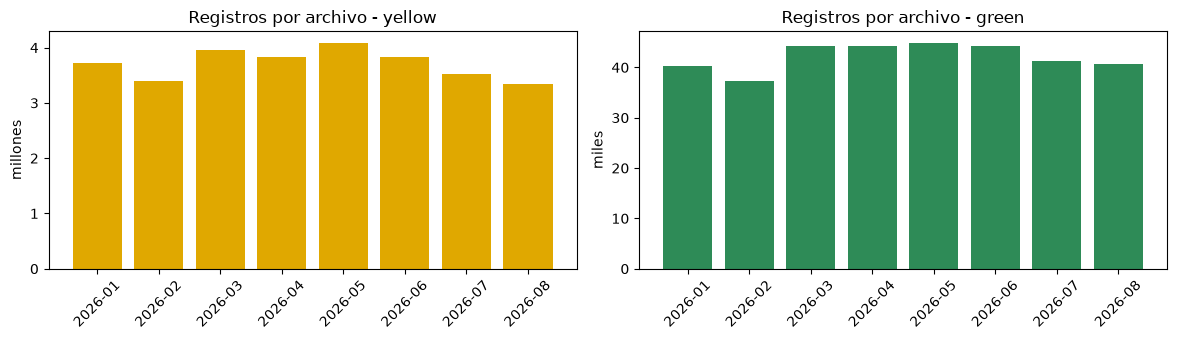

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (tipo, color) in zip(axes, [('yellow', '#e0a800'), ('green', '#2e8b57')]):
    d = por_archivo[por_archivo.taxi_type == tipo]
    ax.bar(d.mes, d.registros / 1e6 if tipo == 'yellow' else d.registros / 1e3, color=color)
    ax.set_title(f'Registros por archivo - {tipo}')
    ax.set_ylabel('millones' if tipo == 'yellow' else 'miles')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 3.3 Columnas presentes (evolución del esquema)

In [6]:
cols = q('q3_04_columnas_por_archivo')
cols[cols.archivos_con_columna < cols.archivos_con_columna.max()]

[q3_04_columnas_por_archivo] Identificar las columnas presentes y si estan en todos los archivos (evolucion del esquema) (3.3).
tiempo: 0.00 s, filas: 43


,taxi_type,columna,archivos_con_columna,desde,hasta
0,green,request_source,3,2026-06,2026-08
22,yellow,request_source,3,2026-06,2026-08


## 3.4 Tipos de datos

In [7]:
q('q3_05_tipos_yellow')[['column_name', 'column_type']]

[q3_05_tipos_yellow] Determinar los tipos de datos (DuckDB) de las columnas de taxis amarillos (3.4).
tiempo: 0.00 s, filas: 21


,column_name,column_type
0,VendorID,INTEGER
1,tpep_pickup_datetime,TIMESTAMP
2,tpep_dropoff_datetime,TIMESTAMP
3,passenger_count,BIGINT
4,trip_distance,DOUBLE
5,RatecodeID,BIGINT
6,store_and_fwd_flag,VARCHAR
7,PULocationID,INTEGER
8,DOLocationID,INTEGER
9,payment_type,BIGINT


In [8]:
q('q3_06_tipos_green')[['column_name', 'column_type']]

[q3_06_tipos_green] Determinar los tipos de datos (DuckDB) de las columnas de taxis verdes (3.4).
tiempo: 0.00 s, filas: 22


,column_name,column_type
0,VendorID,INTEGER
1,lpep_pickup_datetime,TIMESTAMP
2,lpep_dropoff_datetime,TIMESTAMP
3,store_and_fwd_flag,VARCHAR
4,RatecodeID,BIGINT
5,PULocationID,INTEGER
6,DOLocationID,INTEGER
7,passenger_count,BIGINT
8,trip_distance,DOUBLE
9,fare_amount,DOUBLE


In [9]:
q('q3_07_tipos_fisicos_parquet')

[q3_07_tipos_fisicos_parquet] Ver los tipos fisicos/logicos y la compresion con que estan guardadas las columnas en un archivo (3.4).
tiempo: 0.00 s, filas: 20


,columna,tipo_fisico,compression,bytes_comprimidos,bytes_sin_comprimir,ratio
0,tpep_dropoff_datetime,INT64,ZSTD,16957868.0,29064509.0,1.7
1,tpep_pickup_datetime,INT64,ZSTD,16673149.0,29056729.0,1.7
2,total_amount,DOUBLE,ZSTD,6368044.0,6977226.0,1.1
3,trip_distance,DOUBLE,ZSTD,5135846.0,5703597.0,1.1
4,fare_amount,DOUBLE,ZSTD,4713386.0,6208661.0,1.3
5,DOLocationID,INT32,ZSTD,3725745.0,4202515.0,1.1
6,tip_amount,DOUBLE,ZSTD,3427783.0,4825406.0,1.4
7,PULocationID,INT32,ZSTD,3019314.0,3867567.0,1.3
8,extra,DOUBLE,ZSTD,817671.0,1683173.0,2.1
9,cbd_congestion_fee,DOUBLE,ZSTD,503363.0,931716.0,1.9


## 3.5 Muestra de registros

In [10]:
q('q3_08_muestra_yellow')

[q3_08_muestra_yellow] Obtener una muestra reproducible de registros de taxis amarillos (3.5).


tiempo: 0.06 s, filas: 8


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,request_source
0,2,2026-01-01 00:24:41,2026-01-01 00:36:23,1,4.80,1,N,87,162,2,21.2,1.00,0.5,0.00,0.0,1.0,26.95,2.5,0.0,0.75,None
1,1,2026-01-01 02:08:35,2026-01-01 02:21:22,2,2.30,1,N,90,229,1,14.2,4.25,0.5,1.40,0.0,1.0,21.35,2.5,0.0,0.75,None
2,2,2026-01-01 02:01:56,2026-01-01 02:17:20,1,5.69,1,N,80,95,2,26.1,1.00,0.5,0.00,0.0,1.0,28.60,0.0,0.0,0.00,None
3,2,2026-01-01 04:36:54,2026-01-01 04:48:35,1,2.56,1,N,68,79,1,14.2,1.00,0.5,3.99,0.0,1.0,23.94,2.5,0.0,0.75,None
4,1,2026-01-01 09:37:17,2026-01-01 09:42:10,1,0.80,1,N,239,142,1,6.5,2.50,0.5,2.10,0.0,1.0,12.60,2.5,0.0,0.00,None
5,2,2026-01-01 11:29:34,2026-01-01 11:36:19,1,0.74,1,N,161,163,1,7.9,0.00,0.5,3.16,0.0,1.0,15.81,2.5,0.0,0.75,None
6,2,2026-01-01 11:42:55,2026-01-01 11:49:37,1,1.03,1,N,163,186,2,7.9,0.00,0.5,0.00,0.0,1.0,12.65,2.5,0.0,0.75,None
7,2,2026-01-01 13:36:51,2026-01-01 13:45:33,1,0.80,1,N,186,48,2,8.6,0.00,0.5,0.00,0.0,1.0,13.35,2.5,0.0,0.75,None


In [11]:
q('q3_09_muestra_green')

[q3_09_muestra_green] Obtener una muestra reproducible de registros de taxis verdes (3.5).


tiempo: 0.01 s, filas: 8


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,request_source
0,2,2026-01-03 17:06:05,2026-01-03 17:11:27,N,1,74,41,1,1.15,7.2,0.0,0.5,4.00,0.0,NaN,1.0,12.70,1,1,0.00,0.00,None
1,2,2026-01-11 22:28:43,2026-01-11 22:32:53,N,1,74,42,2,0.00,5.8,1.0,0.5,1.66,0.0,NaN,1.0,9.96,1,1,0.00,0.00,None
2,2,2026-01-13 18:36:59,2026-01-13 18:41:12,N,1,43,238,1,1.08,7.2,2.5,0.5,3.49,0.0,NaN,1.0,17.44,1,1,2.75,0.00,None
3,2,2026-01-16 15:15:45,2026-01-16 15:43:34,N,1,244,233,1,9.39,38.0,0.0,0.5,0.00,0.0,NaN,1.0,43.00,2,1,2.75,0.75,None
4,2,2026-01-20 15:12:55,2026-01-20 15:24:05,N,1,82,82,1,1.40,11.4,0.0,0.5,0.00,0.0,NaN,1.0,12.90,2,1,0.00,0.00,None
5,2,2026-01-23 10:19:05,2026-01-23 10:37:24,N,1,74,238,1,3.02,18.4,0.0,0.5,4.53,0.0,NaN,1.0,27.18,1,1,2.75,0.00,None
6,2,2026-01-24 15:40:48,2026-01-24 15:52:07,N,1,65,40,1,1.05,10.7,0.0,0.5,1.59,0.0,NaN,1.0,13.79,1,1,0.00,0.00,None
7,2,2026-01-30 00:16:28,2026-01-30 00:23:47,N,1,75,238,1,1.36,9.3,1.0,0.5,1.77,0.0,NaN,1.0,13.57,1,1,0.00,0.00,None


## 3.6 Problemas de calidad de datos

In [12]:
q('q3_10_perfil_yellow')[['column_name','column_type','min','max','avg','q50','null_percentage']]

[q3_10_perfil_yellow] Perfil estadistico de todas las columnas (min, max, promedio, % nulos, cardinalidad aproximada) para detectar problemas de calidad (3.6).


tiempo: 8.04 s, filas: 21


,column_name,column_type,min,max,avg,q50,null_percentage
0,VendorID,INTEGER,1,7,1.885739809526567,2,0.00
1,tpep_pickup_datetime,TIMESTAMP,2001-01-01 09:23:58,2026-08-31 23:59:59,2026-04-30 15:29:29.519432,2026-04-30 22:21:19.698506,0.00
2,tpep_dropoff_datetime,TIMESTAMP,2001-01-01 16:09:38,2026-09-01 20:16:00,2026-04-30 15:47:08.186216,2026-05-01 04:03:48.985745,0.00
3,passenger_count,BIGINT,0,9,1.2494318488564,1,25.98
4,trip_distance,DOUBLE,0.0,328522.2,5.552940149689999,1.8556140804655057,0.00
5,RatecodeID,BIGINT,1,99,4.527471444398553,1,25.98
6,store_and_fwd_flag,VARCHAR,N,Y,NaN,NaN,25.98
7,PULocationID,INTEGER,1,265,161.57793013617484,161,0.00
8,DOLocationID,INTEGER,1,265,161.05139342003622,162,0.00
9,payment_type,BIGINT,0,5,0.8621735154160195,1,0.00


In [13]:
q('q3_11_perfil_green')[['column_name','column_type','min','max','avg','q50','null_percentage']]

[q3_11_perfil_green] Perfil estadistico de las columnas de taxis verdes (3.6).
tiempo: 0.12 s, filas: 22


,column_name,column_type,min,max,avg,q50,null_percentage
0,VendorID,INTEGER,1,6,2.328351833504393,2,0.00
1,lpep_pickup_datetime,TIMESTAMP,2008-12-31 17:35:31,2026-08-31 23:58:28,2026-05-02 13:25:51.096427,2026-05-04 14:15:55.140659,0.00
2,lpep_dropoff_datetime,TIMESTAMP,2008-12-31 23:16:26,2026-09-02 09:39:37,2026-05-02 13:46:38.833759,2026-05-04 09:04:23.096522,0.00
3,store_and_fwd_flag,VARCHAR,N,Y,NaN,NaN,14.47
4,RatecodeID,BIGINT,1,99,1.2549672434183374,1,14.47
5,PULocationID,INTEGER,1,265,97.32761024460568,75,0.00
6,DOLocationID,INTEGER,1,265,142.8768458147689,140,0.00
7,passenger_count,BIGINT,0,9,1.3006461144694266,1,14.47
8,trip_distance,DOUBLE,0.0,179830.92,13.349507644298376,2.0671644130126743,0.00
9,fare_amount,DOUBLE,-500.0,1676.7,17.014101995170655,13.226265251216487,0.00


In [14]:
problemas = q('q3_12_problemas_calidad')
tabla = problemas.pivot(index='problema', columns='taxi_type', values='registros')
tot = tabla.loc['total_registros']
(tabla.drop('total_registros') / tot * 100).round(3).sort_values('yellow', ascending=False).rename(columns=lambda c: f'% {c}')

[q3_12_problemas_calidad] Cuantificar cada problema de calidad detectado, por tipo de taxi (3.6).


tiempo: 0.53 s, filas: 30


taxi_type,% green,% yellow
problema,,
passenger_count_nulo,14.468,25.979
payment_type_desconocido,14.468,25.979
distancia_cero,3.623,3.206
ratecode_99_invalido,0.001,2.591
duracion_cero_o_negativa,0.069,1.251
total_negativo,0.303,0.545
tarifa_negativa,0.296,0.530
passenger_count_cero,1.343,0.308
duracion_mayor_3h,0.382,0.034


In [15]:
q('q3_13_fechas_fuera_de_rango')

[q3_13_fechas_fuera_de_rango] Ver de que fechas son los registros cuyo pickup no corresponde al mes del archivo (3.6).
tiempo: 0.09 s, filas: 20


,taxi_type,mes_pickup,mes_archivo,registros
0,yellow,2026-08,2026-07,38
1,green,2026-02,2026-01,18
2,yellow,2026-04,2026-06,15
3,yellow,2026-02,2026-03,15
4,yellow,2026-07,2026-08,14
5,green,2026-07,2026-08,12
6,green,2026-05,2026-06,12
7,yellow,2026-01,2026-02,12
8,yellow,2026-04,2026-05,11
9,green,2026-04,2026-05,8


In [16]:
q('q3_14_codigos_categoricos')

[q3_14_codigos_categoricos] Revisar los valores de las columnas categoricas contra el diccionario de datos de la TLC (3.6).


tiempo: 0.44 s, filas: 34


,taxi_type,columna,codigo,registros,pct
0,green,payment_type,1,219980,65.25
1,green,payment_type,2,65921,19.55
2,green,payment_type,NaN,48775,14.47
3,green,payment_type,3,1688,0.50
4,green,payment_type,4,750,0.22
5,green,ratecode_id,1,269152,79.84
6,green,ratecode_id,NaN,48775,14.47
7,green,ratecode_id,5,17739,5.26
8,green,ratecode_id,2,887,0.26
9,green,ratecode_id,4,354,0.11


In [17]:
q('q3_15_request_source')

[q3_15_request_source] Explorar la nueva columna request_source que aparece a mitad de 2026 (3.3 / 3.6).
tiempo: 0.05 s, filas: 29


,taxi_type,mes,request_source,registros
0,green,2026-05,NULL,44921
1,green,2026-06,NULL,37692
2,green,2026-06,A,6471
3,green,2026-07,NULL,34822
4,green,2026-07,A,6428
5,green,2026-07,CC,2
6,green,2026-08,NULL,34377
7,green,2026-08,A,5130
8,green,2026-08,HV0005,1179
9,green,2026-08,CC,1


In [18]:
q('q3_16_impacto_limpieza')

[q3_16_impacto_limpieza] Medir cuantos registros conserva la vista trips_clean despues de aplicar las reglas de calidad (3.6).


tiempo: 0.40 s, filas: 2


,taxi_type,registros_originales,registros_limpios,descartados,pct_conservado
0,yellow,29703355,27884915,1818440,93.88
1,green,337114,309437,27677,91.79


## Conclusiones

- 16 archivos (ene-ago 2026), 30.0 M de registros; yellow representa ~99%.
- El esquema cambia en el tiempo (`request_source` desde junio 2026) y entre tipos de taxi; se usa
  `union_by_name = true` y la vista normalizada `trips`.
- ~26% de yellow no tiene datos de taxímetro (`payment_type = 0`, `passenger_count` NULL).
- Existen fechas imposibles, duraciones ≤ 0, distancias de cientos de miles de millas y montos
  negativos; la vista `trips_clean` los excluye y conserva ~94% de los registros.
- Consultar Parquet directamente permitió todo esto sin cargar los datos: `COUNT(*)` usa metadatos
  y el perfil completo (`SUMMARIZE`) de 29.7 M filas tarda unos segundos.